In [1]:
from kan import KAN, create_dataset
from kan.feynman import get_feynman_dataset
import pandas as pd
import torch
import numpy as np
import sympy as sp
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pathlib import Path

In [2]:
device = "cpu"

def r2(preds,targets):
    pred_mean = torch.mean(preds, dim=[0], keepdim=True)
    target_mean =torch.mean(targets, dim=[0], keepdim=True)
    numerator = torch.sum((preds - pred_mean)*(targets-target_mean), dim=0)**2
    denominator = torch.sum((preds - pred_mean)**2, dim=0)*torch.sum((targets - target_mean)**2, dim=0)
    r2 = numerator/(denominator+1e-4)
    r2 = torch.nan_to_num(r2)
    return r2

def R2(preds, targets):
    pred_mean = torch.mean(preds, dim=[0], keepdim=True)
    target_mean = torch.mean(targets, dim=[0], keepdim=True)
    SS_res = torch.sum((targets - preds)**2, dim=0)
    SS_tot = torch.sum((targets - target_mean)**2, dim=0)
    r2_score = 1 - (SS_res / (SS_tot + 1e-8))
    return torch.nan_to_num(r2_score)

In [3]:
seed = 42
symbols, _, func, ranges = get_feynman_dataset("I.12.1")
train_path = Path('../../../feynmanDataset/train/II.11.17_train.csv')
test_path = Path('../../../feynmanDataset/test/II.11.17_test.csv')


train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)
X_train = torch.tensor(train_df.iloc[:, :-1].values, dtype=torch.float32)
y_train = torch.tensor(train_df.iloc[:, -1].values, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(test_df.iloc[:, :-1].values, dtype=torch.float32)
y_test = torch.tensor(test_df.iloc[:, -1].values, dtype=torch.float32).reshape(-1, 1)
dataset = {'train_input': X_train, 'train_label': y_train, 'test_input': X_test, 'test_label': y_test}

| train_loss: 9.17e-02 | test_loss: 1.14e-01 | reg: 2.92e+00 | : 100%|█| 75/75 [00:16<00:00,  4.48it


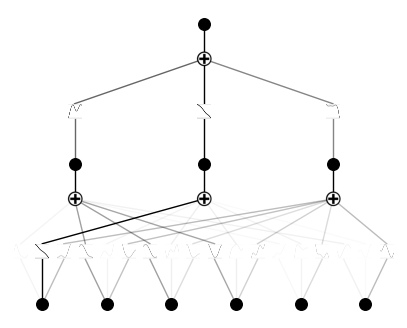

In [4]:
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
# kan =KAN(width=[[len(symbols),0],[2,2],[1,0]], grid=3, k=3, seed=42, device=device)

kan =KAN(width=[X_train.size()[1],3,1], grid=3, k=3, seed=seed, device=device, auto_save=False, affine_trainable=True)

kanFitLoss1 = kan.fit(dataset, opt="LBFGS", steps=75, lamb=0.001);
kan.plot()

In [5]:
# kanLossHistory1test = [x.item() for x in kanFitLoss1['test_loss']]
# plt.plot(kanLossHistory1test)
# kanLossHistory1train = [x.item() for x in kanFitLoss1['train_loss']]
# plt.plot(kanLossHistory1train)
# plt.show()

y_pred_kan = kan(dataset['test_input'])
R2_score_kan = R2(y_pred_kan, dataset['test_label']).item()
r_score_kan = torch.sqrt(r2(y_pred_kan, dataset['test_label'])).item()
print(f"R2 Score KAN: {R2_score_kan}")
print(f"pearson correlation coefficient KAN: {r_score_kan}")

R2 Score KAN: 0.8644128441810608
pearson correlation coefficient KAN: 0.9306355118751526


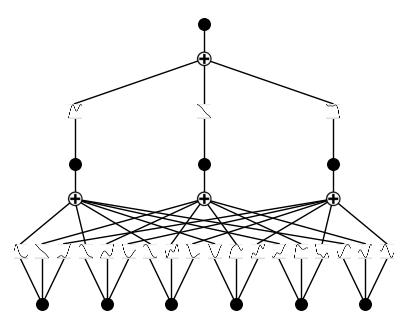

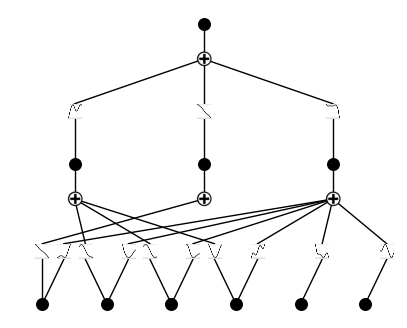

In [6]:
kan.plot(beta=1000)
kan2 = kan.prune()
# kan = kan.prune_node(log_history=False)
kan2.plot(beta=1000)

In [7]:
y_pred_kan = kan2(dataset['test_input'])
R2_score_kan = R2(y_pred_kan, dataset['test_label']).item()
r_score_kan = torch.sqrt(r2(y_pred_kan, dataset['test_label'])).item()
print(f"R2 Score KAN: {R2_score_kan}")
print(f"pearson correlation coefficient KAN: {r_score_kan}")

R2 Score KAN: 0.821682333946228
pearson correlation coefficient KAN: 0.9155312180519104


In [8]:
# Diagnose the scaling issue
from scipy import stats

y_test_np = dataset['test_label'].numpy().flatten()
y_pred_np = y_pred_kan.detach().numpy().flatten()

# Fit a linear regression: y_test = a * y_pred + b
slope, intercept, r_value, p_value, std_err = stats.linregress(y_pred_np, y_test_np)

print(f"Linear relationship: y_true = {slope:.6f} * y_pred + {intercept:.6f}")
print(f"Pearson r: {r_value:.6f}")
print(f"\nMagnitudes:")
print(f"  y_pred range: [{y_pred_np.min():.4f}, {y_pred_np.max():.4f}]")
print(f"  y_test range: [{y_test_np.min():.4f}, {y_test_np.max():.4f}]")
print(f"  y_pred std: {y_pred_np.std():.4f}")
print(f"  y_test std: {y_test_np.std():.4f}")

# If we apply the linear correction
y_pred_corrected = slope * y_pred_kan + intercept
R2_corrected = R2(y_pred_corrected, dataset['test_label']).item()
print(f"\nR² after linear correction: {R2_corrected:.6f}")


Linear relationship: y_true = 0.956785 * y_pred + -0.014495
Pearson r: 0.915531

Magnitudes:
  y_pred range: [-0.1594, 1.1735]
  y_test range: [-0.4539, 1.9158]
  y_pred std: 0.2974
  y_test std: 0.3108

R² after linear correction: 0.838197


In [9]:
# Create 3D surface plots to compare predictions vs targets
# from mpl_toolkits.mplot3d import Axes3D

# # Create a meshgrid covering the input space
# x_min, x_max = X_test[:, 0].min() - 0.1, X_test[:, 0].max() + 0.1
# y_min, y_max = X_test[:, 1].min() - 0.1, X_test[:, 1].max() + 0.1

# x_grid = np.linspace(x_min, x_max, 30)
# y_grid = np.linspace(y_min, y_max, 30)
# X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)

# # Flatten for predictions
# grid_points = np.column_stack([X_mesh.ravel(), Y_mesh.ravel()])
# grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

# # Get predictions on the grid
# with torch.no_grad():
#     Z_pred = kan2(grid_tensor).numpy().reshape(X_mesh.shape)

# # Get actual values on the grid (from test data - nearest neighbor)
# # For exact targets, we'd need the true function, so we'll use test data points
# Z_test_points = y_test.numpy().flatten()

# # Create figure with two subplots
# fig = plt.figure(figsize=(16, 6))

# # Plot 1: Predicted surface
# ax1 = fig.add_subplot(121, projection='3d')
# surf1 = ax1.plot_surface(X_mesh, Y_mesh, Z_pred, cmap='viridis', alpha=0.8, edgecolor='none')
# ax1.scatter(X_test[:, 0].numpy(), X_test[:, 1].numpy(), Z_test_points, 
#            color='red', s=20, alpha=0.6, label='Test data (actual)')
# ax1.set_xlabel('X₀')
# ax1.set_ylabel('X₁')
# ax1.set_zlabel('Output')
# ax1.set_title('KAN Model Predictions')
# fig.colorbar(surf1, ax=ax1, shrink=0.5)

# # Plot 2: Residuals (pred - target)
# # Map test points to grid to compute residuals
# from scipy.spatial import cKDTree
# tree = cKDTree(grid_points)
# distances, indices = tree.query(X_test.numpy())
# residuals = Z_pred.ravel()[indices] - Z_test_points

# ax2 = fig.add_subplot(122, projection='3d')
# # Plot residuals as scatter
# scatter = ax2.scatter(X_test[:, 0].numpy(), X_test[:, 1].numpy(), residuals,
#                      c=residuals, cmap='RdBu_r', s=50, alpha=0.8)
# ax2.set_xlabel('X₀')
# ax2.set_ylabel('X₁')
# ax2.set_zlabel('Residual (Pred - Target)')
# ax2.set_title('Prediction Residuals')
# ax2.set_zlim([residuals.min() - 0.1, residuals.max() + 0.1])
# fig.colorbar(scatter, ax=ax2, shrink=0.5)

# plt.tight_layout()
# plt.show()

# print(f"Mean residual: {np.mean(residuals):.6f}")
# print(f"Std residual: {np.std(residuals):.6f}")
# print(f"Max absolute residual: {np.max(np.abs(residuals)):.6f}")


In [10]:
# kan.suggest_symbolic(0,0,0, weight_simple=0.8)
# kan.suggest_symbolic(1,1,0, weight_simple=0.8)

kan2.auto_symbolic(weight_simple=0.8)
# yt = kan2(dataset['test_input'])
# kan2.plot()
kanFitLoss2 = kan2.fit(dataset, opt="Adam", lr=0.001,lamb=0.001, steps=1000,update_grid=False, singularity_avoiding=True);

from kan.utils import ex_round

ex_round(kan2.symbolic_formula()[0][0],4)

fixing (0,0,0) with 0
fixing (0,0,1) with x, r2=0.9945892691612244, c=1
fixing (0,0,2) with x, r2=0.5424823760986328, c=1
fixing (0,1,0) with x, r2=0.9438655972480774, c=1
fixing (0,1,1) with 0
fixing (0,1,2) with x^2, r2=0.9584187865257263, c=2
fixing (0,2,0) with sin, r2=0.9996493458747864, c=2
fixing (0,2,1) with 0
fixing (0,2,2) with x, r2=0.4511083960533142, c=1
fixing (0,3,0) with sin, r2=0.9994450211524963, c=2
fixing (0,3,1) with 0
fixing (0,3,2) with x, r2=0.7153714299201965, c=1
fixing (0,4,0) with 0
fixing (0,4,1) with 0
fixing (0,4,2) with x, r2=0.24079419672489166, c=1
fixing (0,5,0) with 0
fixing (0,5,1) with 0
fixing (0,5,2) with cos, r2=0.9791781902313232, c=2
fixing (1,0,0) with x, r2=0.0007663628784939647, c=1
fixing (1,1,0) with x, r2=0.9926269054412842, c=1
fixing (1,2,0) with x, r2=0.005081855691969395, c=1


| train_loss: 1.41e-01 | test_loss: 1.31e-01 | reg: 0.00e+00 | : 100%|█| 1000/1000 [00:20<00:00, 48.
c:\Users\Maarten\codeProjects\MLenv\Lib\site-packages\sympy\core\sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  return sympify(float(a))


0.2909*x_1 + 0.0046*x_2 + 0.0048*x_3 - 0.0135*x_4 + 0.0027*x_5 - 0.0001*(0.6046 - 8.1694*x_2)**2 - 0.0016*sin(0.9908*x_3 + 6.2179) + 0.0143*sin(1.6504*x_4 - 0.5149) + 0.015*cos(1.4748*x_6 - 6.3834) + 0.4907

In [11]:
y_pred_kan = kan2(dataset['test_input'])
R2_score_kan = R2(y_pred_kan, dataset['test_label']).item()
r_score_kan = torch.sqrt(r2(y_pred_kan, dataset['test_label'])).item()
print(f"R2 Score KAN: {R2_score_kan}")
print(f"pearson correlation coefficient KAN: {r_score_kan}")


R2 Score KAN: 0.8230810165405273
pearson correlation coefficient KAN: 0.9073077440261841


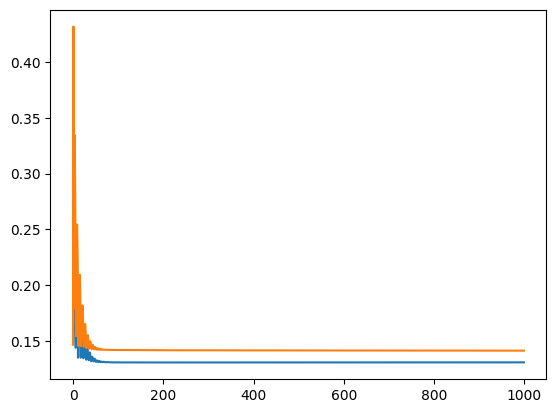

In [12]:
kanLossHistory2test = [x.item() for x in kanFitLoss2['test_loss']]
plt.plot(kanLossHistory2test)
kanLossHistory2train = [x.item() for x in kanFitLoss2['train_loss']]
plt.plot(kanLossHistory2train)
plt.show()
